# Input

In [484]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata_bulk, retrieve_net, calculate_tf_activity, retrieve_sig_stats, get_consensus_net

from ciim.src.clock.helper import clock_save_dir, predict_age, prepare_input

# - settings
feature_type = 'gene_expression' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'ridge' #'tabpfn'
tune_model = True
version = 'v1.0'
temp_dir = f'{save_dir}/output/temp/'

cell_types = ['CD8T'] # ['CD4T','CD8T', 'MONO', 'B', 'NK']
n_cell_types = len(cell_types)
# datasets_training = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese']

#TODO: use scvi extending embding

In [485]:
if False:
    n_target = {}
    net_dict = {}
    for cell_type in cell_types:
        net = get_consensus_net(cell_type=cell_type)
        net_dict[cell_type] = net
        n_target[cell_type] = net['target'].nunique()
    print(n_target)

    cell_type = 'MONO'
    net = net_dict[cell_type]
    c_outdegree = net.groupby('source').size().sort_values(ascending=False).head(20)
    import matplotlib.pyplot as plt

    plt.figure(figsize=(2, 4))
    c_outdegree.plot(kind='barh')
    plt.xlabel('Source Gene')
    plt.title(f'Outdegree: {cell_type}')

# Calculate feature space using consensus GRNs -> smoothed

In [486]:
if False:
    from ciim.src.clock.helper import prepare_input, predict_age
    for feature_type in ['gene_expression']:
        os.makedirs(f'{save_dir}/{feature_type}_smoothed/', exist_ok=True)
        for dataset in datasets_all+datasets_disease+datasets_drug_perturbation:
            for cell_type in cell_types:
                adata = prepare_input(dataset, cell_type, feature_type=feature_type, data_type='bulk')
                adata.write(f'{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_bulk.h5ad')

# Train

In [488]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *aging_clock_train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,

    ]
    if tune_model:
        cmd += ["--tune_model"]

    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD8T --datasets_training data1 data7_allTPs_jalil SLE_European data13_Japanese --feature_type gene_expression --data_type bulk --reg_type ridge --version v1.0 --temp_dir /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//output/temp/ --tune_model


python(54335) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


{'cell_types': ['CD8T'], 'datasets_training': ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'v1.0', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//output/temp/'}
building model for cell type: CD8T


/Users/jno24/miniconda3/envs/py10/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
  0%|          | 0/30 [00:00<?, ?it/s]

(1515, 2780) (1515,)


Best trial: 22. Best value: 0.157965: 100%|██████████| 30/30 [00:06<00:00,  4.98it/s]



Best alpha: 446.5791, Best CV performance: 0.1580


In [464]:
if reg_type == 'NN':
    loss = np.load('tmp/loss.npy')
    plt.plot(loss)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Loss over Epochs')
    plt.grid(True)
    plt.show()

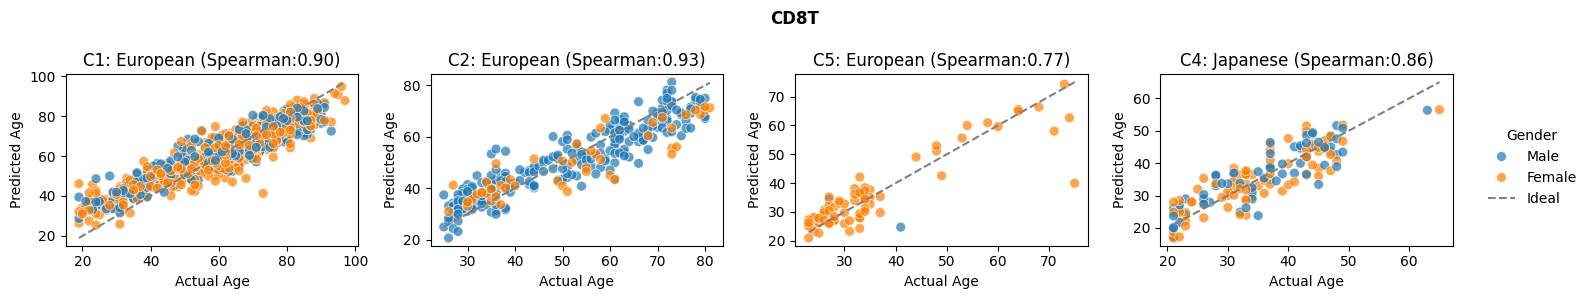

In [489]:
from ciim.src.clock.helper import evaluate_groupwise_median
for cell_type in cell_types:
    adata_all = ad.read_h5ad(f"{temp_dir}{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
    obs = adata_all.obs.copy()
    obs['sex'] = obs['sex'].astype(str)
    obs['donor_id'] = obs['donor_id'].astype(str)
    obs['age'] = obs['age'].astype(float)
    obs['predicted_age'] = obs['predicted_age'].astype(float)
    datasets = obs['dataset'].unique()
    fig, axes = plt.subplots(1, len(datasets), figsize=(4*len(datasets), 3))
    i = 0
    for dataset in datasets:
        ax = axes[i] if len(datasets) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
        obs_d = obs_d.groupby(['donor_id', 'age', 'sex'])['predicted_age'].median().reset_index()
        sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders, hue='sex')
        min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
        ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

        ax.set_xlabel("Actual Age")
        ax.set_ylabel("Predicted Age")

        spearman = evaluate_groupwise_median(obs_d)['Spearman']
        ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")

        i+=1
        ax.get_legend().remove()
    ax.legend(loc=(1.1, .2), frameon=False, title='Gender')

    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()

# Collinear modules

In [466]:
if False:
    cell_type = 'CD8T'

    adata = sc.read_h5ad(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")

    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    X = adata.X

    X = X.toarray() if hasattr(X, 'toarray') else X  # Convert sparse to dense if needed

    X_scaled = StandardScaler().fit_transform(X)
    X_df = pd.DataFrame(X_scaled, columns=adata.var_names)

    vif = pd.Series([variance_inflation_factor(X_df.values, i) for i in range(X_df.shape[1])],
                    index=X_df.columns)
    vif.min()


# Feature importance

In [467]:
if False:
    from ciim.src.clock.helper import stability_selection_shap, retrieve_function
    def select_features(cell_type, top_q=None, top_features=50):
        
        return gene_names
    shap_rr_store = []
    for cell_type in cell_types: # feature selction for all cell types
        model, gene_names = retrieve_function(reg_type, cell_type, data_type, feature_type, version)
        # - get the data
        adata = ad.read_h5ad(f"{temp_dir}{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
        adata = adata[:, gene_names].copy() # select only the genes used in the model
        X = adata.X.copy()
        y = adata.obs['age'].values
        # - retrieve the model and feature space 
        
        # assert (gene_names==adata.var_names).all(), "Gene names do not match!"
        # - feature selection
        rr = stability_selection_shap(gene_names, model, X.copy(), y, top_q=None, top_features=50)
        rr['cell_type'] = cell_type
        shap_rr_store.append(rr)
    shap_rr = pd.concat(shap_rr_store)
    # shap_rr[(shap_rr['cell_type'] == 'CD8T')].sort_values('importance', ascending=False, key=abs)

# Evaluation

In [468]:
force_write = True

In [ ]:
evaluate_datasets = datasets_all + datasets_disease + datasets_drug_perturbation # 'data1', 'data7_allTPs_jalil', 'data12', 'SLE_European', 'data13_Korean' , 'data13_Japanese', 
# evaluate_datasets = ['data13_Korean', 'data7_allTPs_jalil', 'SLE_European', 'Covid_50MHH', 'CXCL9']
prediction_file = f'{clock_save_dir}/prediction/{feature_type}_{data_type}_{reg_type}.csv'
if (force_write) or not os.path.exists(prediction_file):
    os.makedirs(f'{clock_save_dir}/prediction', exist_ok=True)
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs.rename(columns={'disease': 'condition', 'treatment':'condition', 'Max_WHO_Group':'condition'}, inplace=True)
            if 'condition' not in adata.obs.columns:
                adata.obs['condition'] = 'healthy'
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type)
                obs = adata_c.obs[['age', 'predicted_age', 'sex', 'donor_id']].copy() 
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    obs.to_csv(prediction_file, index=False)
else:
    obs = pd.read_csv(prediction_file)
obs.head()

,age,predicted_age,sex,donor_id,dataset,cell_type,condition
1962,73,65.279989,Female,Data1_1000_1001,data1,CD8T,healthy
1963,57,60.319194,Female,Data1_1001_1002,data1,CD8T,healthy
1964,73,69.400058,Male,Data1_1002_1003,data1,CD8T,healthy
1965,58,58.966026,Female,Data1_1003_1004,data1,CD8T,healthy
1966,74,61.689658,Female,Data1_1004_1005,data1,CD8T,healthy


## Performance on train data

### Line plot

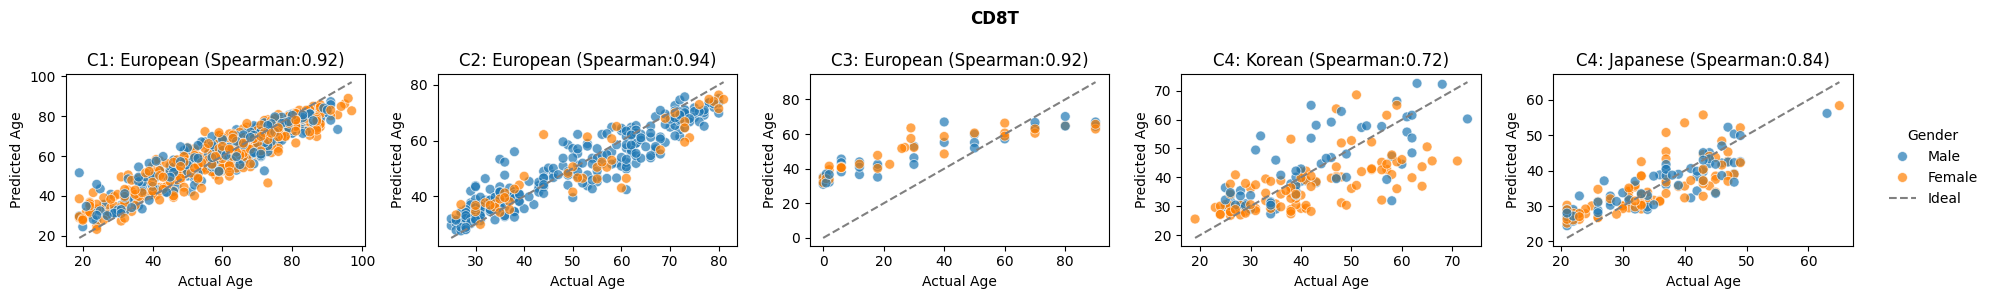

In [470]:
from ciim.src.clock.helper import evaluate_groupwise_median

obs['sex'] = obs['sex'].astype('str')

datasets_healthy = [d for d in  datasets_all if d in obs[(obs['condition'] == 'healthy')]['dataset'].unique()]

if True:
    for cell_type in cell_types:
        fig, axes = plt.subplots(1, len(datasets_healthy), figsize=(4*len(datasets_healthy), 3))
        i = 0
        for dataset in datasets_healthy:
            ax = axes[i] if len(datasets_healthy) > 1 else axes
            obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
            obs_d = obs_d.groupby(['donor_id', 'age', 'sex'])['predicted_age'].median().reset_index()


            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders, hue='sex')
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")
            spearman = evaluate_groupwise_median(obs_d)['Spearman']
            ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")

            i+=1
            ax.get_legend().remove()
        ax.legend(loc=(1.1, .2), frameon=False, title='Gender')
        
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

### Summary plot

In [471]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.stats import spearmanr
from ciim.src.clock.helper import evaluate_groupwise_median


datasets_healthy = ['data1', 'data7_allTPs_jalil', 'SLE_European' ,'data13_Japanese', 'data12', 'data13_Korean'] 
datasets_healthy = [d for d in datasets_healthy if d in obs['dataset'].unique()]

scores = []
for cell_type in cell_types:
    for dataset in datasets_healthy:
        df = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
        obs_d = df.groupby(['donor_id', 'age'])['predicted_age'].median().reset_index()

        rr = evaluate_groupwise_median(obs_d)
        spearman = rr['Spearman']
        r2 =  rr['R2']

        scores.append({
            'cell_type': cell_type,
            'dataset': dataset,
            'Spearman': spearman,
            'R2': r2
        })
scores_df = pd.DataFrame(scores)
scores_long = scores_df.melt(id_vars=['cell_type', 'dataset'], 
                              value_vars=['Spearman', 'R2'], 
                              var_name='metric', value_name='score')
scores_long['dataset'] = scores_long['dataset'].apply(lambda name: surrogate_names.get(name, name))
scores_long.head()

,cell_type,dataset,metric,score
0,CD8T,C1: European,Spearman,0.918416
1,CD8T,C2: European,Spearman,0.936866
2,CD8T,C5: European,Spearman,0.761731
3,CD8T,C4: Japanese,Spearman,0.841921
4,CD8T,C3: European,Spearman,0.920061


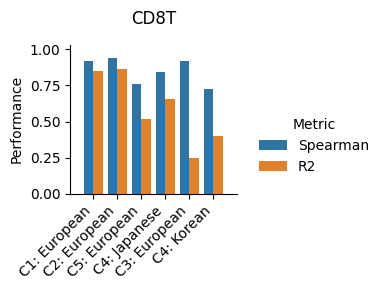

In [472]:
def multipanel_plot():
    fig, axes = plt.subplots(1, len(cell_types), figsize=(3*len(cell_types)+1, 3), sharey=True)
    for i, (cell_type) in enumerate(cell_types):
        ax = axes[i] if len(cell_types) > 1 else axes
        df_s = scores_long[scores_long['cell_type'] == cell_type]
        df_s['score'] = df_s['score'].clip(lower=0, upper=1) # clip the scores

        sns.barplot(
                ax=ax,
                data=df_s,
                x='dataset', y='score', hue='metric')
        ax.set_title(f"{cell_type}", pad=15)
        ax.set_ylabel("Performance")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)
        ax.margins(y=.1, x=.1)
    ax.legend(loc=(1.1, .1), title='Metric', frameon=False, fontsize=10)
    
    plt.tight_layout()
    
multipanel_plot()

#### ridge

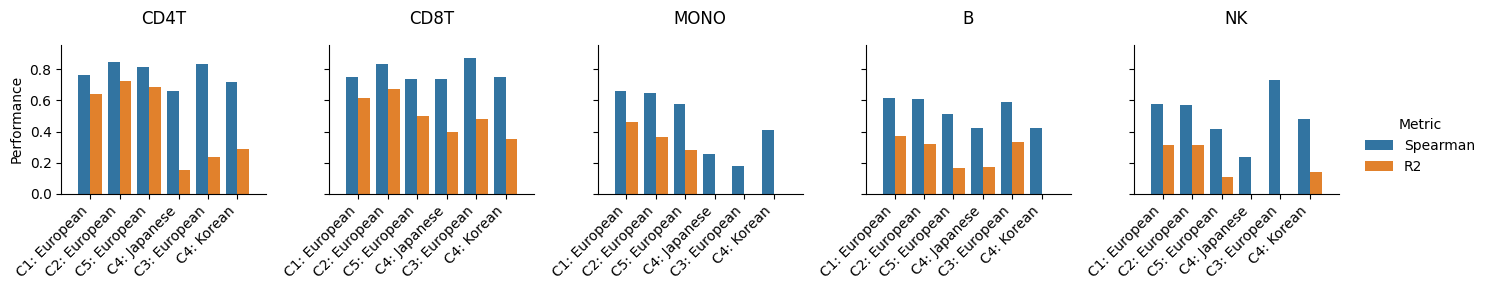

# Performance on disease

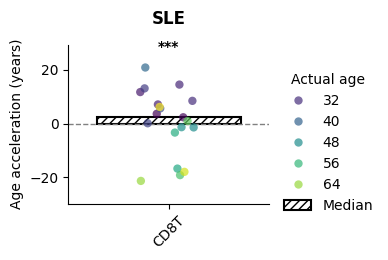

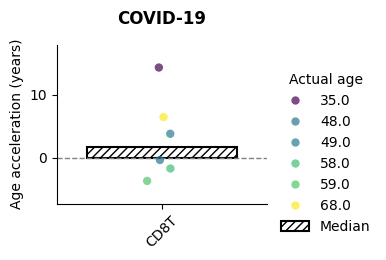

In [473]:
def wrapper_age_acceleration_disease(obs, disease_dataset):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.stats import ttest_1samp
    from statsmodels.stats.multitest import multipletests
    import numpy as np

    if disease_dataset == 'Covid_50MHH':
        disease_name = 'COVID-19'
        ctr = 'mild'
        cond = 'severe'
    elif disease_dataset == 'SLE_European':
        disease_name = 'SLE'
        ctr = 'normal'
        cond = 'systemic lupus erythematosus'

    obs_disease = obs[obs['dataset'] == disease_dataset].copy()

    obs_disease['age'] = obs_disease['age'].astype(float)
    obs_disease['donor_id'] = obs_disease['donor_id'].astype(str)
    obs_disease['cell_type'] = obs_disease['cell_type'].astype(str)
    obs_disease['condition'] = obs_disease['condition'].astype(str)

    df_pivot = obs_disease.pivot_table(index=['age', 'cell_type'], columns='condition', values='predicted_age')
    df_pivot = df_pivot.reset_index()
    df_pivot['diff'] = df_pivot[cond] - df_pivot[ctr]
    df_pivot = df_pivot[~df_pivot['diff'].isna()]
    df_pivot['cell_type'] = pd.Categorical(df_pivot['cell_type'], categories=cell_types, ordered=True)

    fig, ax = plt.subplots(figsize=(4, 2.7))

    # Stripplot
    sns.stripplot(
        ax=ax, data=df_pivot, y='diff', x='cell_type',
        alpha=0.7, hue='age', palette='viridis', s=6
    )

    # Bar plot for medians (frame-only bars)
    medians = df_pivot.groupby('cell_type')['diff'].median().reindex(cell_types)
    bar_x = np.arange(len(cell_types))
    ax.bar(
        bar_x, medians, width=0.5, fill=False, edgecolor='black', linewidth=1.5,
        zorder=0.1, label='Median', hatch='////'
    )

    # Statistical tests (unpaired)
    pvals = []
    mean_diffs = []
    for cell_type in cell_types:
        group = obs_disease[obs_disease['cell_type'] == cell_type]
        group_ctr = group[group['condition'] == ctr]['predicted_age']
        group_cond = group[group['condition'] == cond]['predicted_age']

        if len(group_ctr) > 1 and len(group_cond) > 1:
            from scipy.stats import ttest_ind
            _, pval = ttest_ind(group_cond, group_ctr, equal_var=False)  # Welch’s t-test
            mean_diff = group_cond.mean() - group_ctr.mean()
        else:
            pval = 1.0
            mean_diff = np.nan

        pvals.append(pval)
        mean_diffs.append(mean_diff)

    _, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')
    for i, (mean_diff, pval_fdr) in enumerate(zip(mean_diffs, pvals_fdr)):
        
        star = '***' if pval_fdr < 0.001 else '**' if pval_fdr < 0.01 else '*' if pval_fdr < 0.05 else ''
        text = f"{star}"
        y_max = df_pivot[df_pivot['cell_type'] == cell_types[i]]['diff'].max()
        ax.text(i, y_max + 5, text, ha='center', va='bottom', fontsize=10, weight='bold', color='black')

    ax.set_ylabel("Age acceleration (years)")
    ax.set_xlabel("")
    ax.set_xticks(bar_x)
    ax.set_xticklabels(cell_types, rotation=45)
    ax.spines[['top', 'right']].set_visible(False)
    ax.margins(x=0.2, y=0.2)
    ax.legend(title='Actual age', bbox_to_anchor=(1.01, .9), loc='upper left', frameon=False)
    ax.axhline(0, linestyle='--', color='gray', linewidth=1)
    ax.set_title(f"{disease_name}", fontsize=12, weight='bold', pad=15)
    plt.tight_layout()

# Call the function
wrapper_age_acceleration_disease(obs, disease_dataset='SLE_European')
wrapper_age_acceleration_disease(obs, disease_dataset='Covid_50MHH')

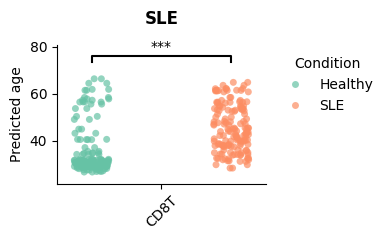

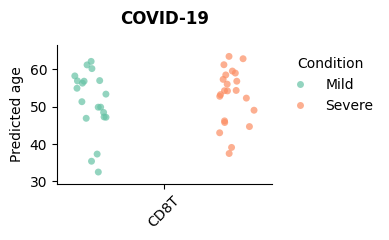

In [ ]:
def wrapper_age_acceleration_disease(obs, disease_dataset):
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt
    from scipy.stats import ttest_ind
    from statsmodels.stats.multitest import multipletests
    import numpy as np

    if disease_dataset == 'Covid_50MHH':
        disease_name = 'COVID-19'
        ctr = 'mild'
        cond = 'severe'
    elif disease_dataset == 'SLE_European':
        disease_name = 'SLE'
        ctr = 'normal'
        cond = 'systemic lupus erythematosus'

    obs_disease = obs[obs['dataset'] == disease_dataset].copy()
    obs_disease['age'] = obs_disease['age'].astype(float)
    obs_disease['donor_id'] = obs_disease['donor_id'].astype(str)
    obs_disease['cell_type'] = obs_disease['cell_type'].astype(str)
    obs_disease['condition'] = obs_disease['condition'].astype(str)

    # Only keep relevant conditions
    obs_disease = obs_disease[obs_disease['condition'].isin([ctr, cond])]
    obs_disease['cell_type'] = pd.Categorical(obs_disease['cell_type'], categories=cell_types, ordered=True)

    fig, ax = plt.subplots(figsize=(4, 2.5))

    # Prepare a grouping variable for (cell_type, condition)
    obs_disease['group'] = obs_disease['cell_type'].astype(str) + ' | ' + obs_disease['condition']

    obs_disease_c = obs_disease.copy()
    obs_disease_c['condition'] = obs_disease_c['condition'].apply(lambda x: surrogate_names.get(x, x))
    if disease_dataset == 'Covid_50MHH':
        obs_disease_c['condition'] = obs_disease_c['condition'].astype(CategoricalDtype(categories=['Mild', 'Severe'], ordered=True))
    elif disease_dataset == 'SLE_European':
        obs_disease_c['condition'] = obs_disease_c['condition'].astype(CategoricalDtype(categories=['Healthy', 'SLE'], ordered=True))
    # Plot stripplot
    sns.stripplot(
        data=obs_disease_c,
        x='cell_type', y='predicted_age', hue='condition',
        dodge=True, jitter=True, alpha=0.7, ax=ax, palette='Set2', size=5
    )

    # Statistical test and brackets
    pvals = []
    brackets = []
    for i, cell_type in enumerate(cell_types):
        data_ctr = obs_disease[(obs_disease['cell_type'] == cell_type) & (obs_disease['condition'] == ctr)]['predicted_age']
        data_cond = obs_disease[(obs_disease['cell_type'] == cell_type) & (obs_disease['condition'] == cond)]['predicted_age']

        if len(data_ctr) > 1 and len(data_cond) > 1:
            _, pval = ttest_ind(data_ctr, data_cond, equal_var=False)
        else:
            pval = 1.0

        pvals.append(pval)

        # Save bracket info: x positions, height, and p-value
        if len(data_ctr) > 0 and len(data_cond) > 0:
            x1, x2 = i - 0.2, i + 0.2
            y_max = max(data_ctr.max(), data_cond.max())
            brackets.append((x1, x2, y_max + 3, pval))

    # FDR correction
    _, pvals_fdr, _, _ = multipletests(pvals, method='fdr_bh')

    # Add brackets and stars
    for i, (x1, x2, y, pval_fdr) in enumerate(zip([b[0] for b in brackets], [b[1] for b in brackets], [b[2] for b in brackets], pvals_fdr)):
        star = '***' if pval_fdr < 0.001 else '**' if pval_fdr < 0.01 else '*' if pval_fdr < 0.05 else ''
        bracket_height = 2.5  # You can adjust this value as needed
        y_bracket = y + 4
        if star:
            ax.plot([x1, x1, x2, x2],
                    [y_bracket, y_bracket + bracket_height, y_bracket + bracket_height, y_bracket],
                    lw=1.5, color='black')
            ax.text((x1 + x2) / 2,
                    y_bracket + bracket_height + 1,
                    star,
                    ha='center', va='bottom', fontsize=10)

    ax.set_ylabel("Predicted age")
    ax.set_xlabel("")
    ax.set_xticklabels(cell_types, rotation=45)
    ax.spines[['top', 'right']].set_visible(False)
    ax.margins(x=0.1, y=0.1)
    ax.legend(title='Condition', bbox_to_anchor=(1.01, 1), loc='upper left', frameon=False)
    ax.set_title(f"{disease_name}", fontsize=12, weight='bold', pad=15)
    plt.tight_layout()
wrapper_age_acceleration_disease(obs, disease_dataset='SLE_European')
wrapper_age_acceleration_disease(obs, disease_dataset='Covid_50MHH')


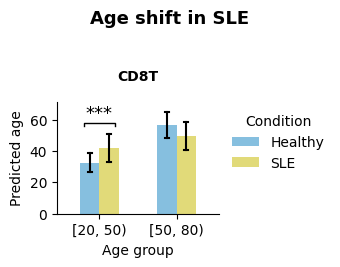

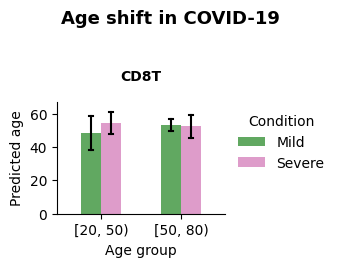

In [ ]:
from ciim.src.clock.plots import wrapper_plot_age_acceleration_disease_bins

# Example usage (make sure n_cell_types, cell_types, and surrogate_names are defined)
wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='SLE_European')
wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='Covid_50MHH')

### Line plot

In [476]:
import scipy.stats as stats

if False:
    for cell_type in cell_types:
        fig, axes = plt.subplots(1, len(conds), figsize=(4*len(conds), 3))
        for i, cond in enumerate(conds):
            ax = axes[i] if len(conds) > 1 else axes
            obs_d = obs_disease[(obs_disease['cell_type'] == cell_type) & (obs_disease['condition'] == cond)].copy()
            obs_d = obs_d.groupby(['donor_id', 'age'])['predicted_age'].median().reset_index()
            # - plot the goodness
            age_diff = obs_d['predicted_age'] - obs_d['age']
            
            # One-sample t-test
            t_stat, p_value = stats.ttest_1samp(age_diff, 0)
            mean_diff = age_diff.mean()
            
            # plt.title(f"{cond}\np = {p_value:.4g}, Mean age diff = {mean_diff:.2f}")

            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders)
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")

            spearman = spearmanr(obs_d['age'], obs_d['predicted_age'])[0]
            ax.set_title(f"{surrogate_names.get(cond, cond)} (Spearman:{spearman:.2f}) \n (Mean diff: {mean_diff:.2f}, p_value: {p_value:.4g})")
            # ax.get_legend().remove()
            
            i+=1
        
        # ax.legend(loc=(1.05, .2), frameon=False)
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()


# Drug perturbation

In [477]:
obs_cxcl9 = obs[obs['dataset'] == 'CXCL9'].copy() 
obs_cxcl9['condition'].unique()

array(['0 h Unstimulated', '24 h LPS', '24 h LPS + metformin',
       '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib',
       '24 h RPMI', '24 h RPMI + metformin',
       '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib',
       '24 h rhCXCL9', '24 h rhIFN-γ'], dtype=object)

In [478]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'Met.',
    # '24 h LPS + metformin + ruxolitinib': 'LPS / Met+Rux', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Met',
    # '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met+Rux',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}

experiments = [
                # ('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                # ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                # ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                ('24 h LPS', '24 h LPS + metformin'),
                ('24 h LPS', '24 h LPS + ruxolitinib'),
                # ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                ]
n_exp = len(experiments)

In [479]:
from statsmodels.stats.multitest import multipletests

# Store raw p-values and labels for later correction
raw_pvals = []
test_labels = [] 
slopes = []

def test_paired(df_sub):
    df_pivot = df_sub.pivot(index='donor_id', columns='condition', values='predicted_age').dropna()
    t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
    slope = (df_pivot[treatment] - df_pivot[ctr]).mean()
    return p_value, slope

def test_mixed_effect(df_sub):
    import statsmodels.formula.api as smf
    df_sub['condition'] = pd.Categorical(df_sub['condition'], categories=[ctr, treatment])
    # Fit the mixed effects model
    model = smf.mixedlm("predicted_age ~ condition", df_sub, groups=df_sub["donor_id"])
    result = model.fit()
    # # Summary of the model
    # print(result.summary())
    # Extract p-value and fixed effect estimate for treatment
    p_value = result.pvalues[f"condition[T.{treatment}]"]
    slope = result.params[f"condition[T.{treatment}]"]
    return p_value, slope
for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    for i, (ctr, treatment) in enumerate(experiments):
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        if df_sub.shape[0] < 2:
            continue  # Skip if not enough data
        
        if 'bulk' in data_type:
            p_value, slope = test_paired(df_sub)

        elif data_type == 'metacell':
            df_sub = df_sub.groupby(['donor_id', 'condition'])['predicted_age'].median().reset_index()
            p_value, slope = test_paired(df_sub)
            # p_value, slope = test_mixed_effect(df_sub)
        else:
            raise ValueError("Unsupported data type")
        raw_pvals.append(p_value)
        slopes.append(slope)
        test_labels.append((cell_type, ctr, treatment))

# Apply FDR correction
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Optionally: map corrected p-values back to plotting
pval_map = {
    (cell_type, ctr, treatment): (pval, slope)
    for (cell_type, ctr, treatment), pval, slope in zip(test_labels, corrected_pvals, slopes)
}

# Redraw plots with adjusted p-values
unique_donors = obs_cxcl9['donor_id'].unique()
donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))  # or use 'tab20', 'Set3', etc.


### All sig and not sig ones

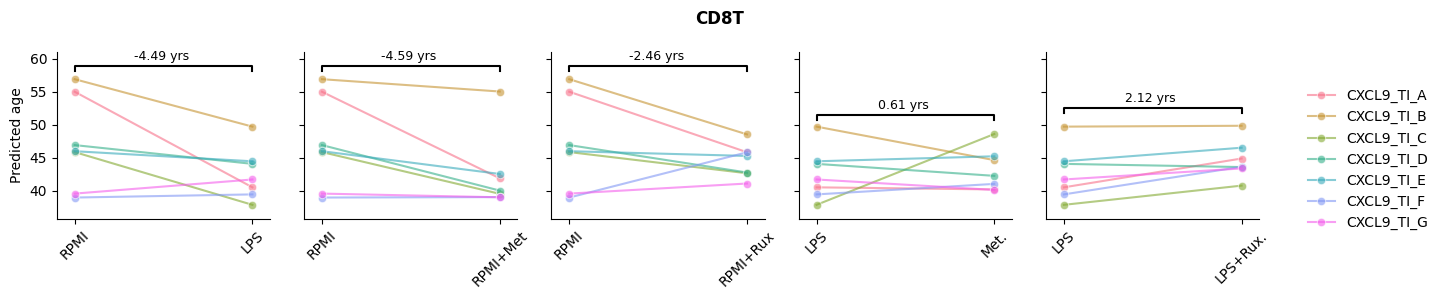

In [480]:
alpha = 0.05  # significance threshold

for cell_type in cell_types:
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()
    fig, axes = plt.subplots(1, n_exp, figsize=(2.5 * n_exp + 2, 3), sharey=True)

    if n_exp == 1:
        axes = [axes]

    for i, (ctr, treatment) in enumerate(experiments):
        ax = axes[i]
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_id', columns='condition', values='predicted_age')
        unique_donors = df_pivot.index.unique()
        donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))

        available_conditions = [cond for cond in [ctr, treatment] if cond in df_pivot.columns]
        if len(available_conditions) < 2:
            continue  # Skip if not both conditions are present

        df_plot = df_pivot.reset_index().melt(
            id_vars='donor_id',
            value_vars=available_conditions,
            var_name='condition',
            value_name='predicted_age'
        )

        df_plot['condition'] = df_plot['condition'].apply(lambda name: pretty_names.get(name, name))
        sns.lineplot(
            data=df_plot, x='condition', y='predicted_age',
            hue='donor_id', marker='o', alpha=0.6, ax=ax,
            legend=True, palette=donor_palette
        )

        # Bracket annotation
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        
        xticks = list(ax.get_xticks())
        x1, x2 = xticks[0], xticks[1]

        group_stats = df_plot.groupby('condition')['predicted_age'].agg(['mean', 'std'])
        cond1, cond2 = df_plot['condition'].unique()
        y1 = group_stats.loc[cond1, 'mean'] + group_stats.loc[cond1, 'std']
        y2 = group_stats.loc[cond2, 'mean'] + group_stats.loc[cond2, 'std']
        y_bracket = max(y1, y2) + 5

        h = 0.8  # height of bracket
        ax.plot([x1, x1, x2, x2], [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
                lw=1.5, c='black')
        
        ax.text((x1 + x2) / 2, y_bracket + 0.4, f"{slope:.2f} yrs {star}",
                ha='center', va='bottom', fontsize=9)

        ax.set_title("")  # No text in title
        ax.set_ylabel("Predicted age")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.margins(x=0.1, y=0.1)
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)

    ax.legend(loc=(1.2, -.1), frameon=False)
    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

### Only sig ones

In [481]:
alpha = 0.05  # significance threshold

for cell_type in cell_types:
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_id', 'condition', 'predicted_age']].copy()

    significant_experiments = [
        (ctr, treatment) for (ctr, treatment) in experiments
        if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[0] < alpha
    ]
    if not significant_experiments:
        continue

    fig, axes = plt.subplots(1, len(significant_experiments), figsize=(2 * len(significant_experiments) + 1, 2.7), sharey=True)
    if len(significant_experiments) == 1:
        axes = [axes]

    for i, (ctr, treatment) in enumerate(significant_experiments):
        ax = axes[i]
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_id', columns='condition', values='predicted_age')
        df_pivot['donor_id'] = ['Donor ' + str(i+1) for i, d in enumerate(df_pivot.index)]
        df_pivot.set_index('donor_id', inplace=True)
        df_pivot = df_pivot.dropna(subset=[ctr, treatment], how='any')

        unique_donors = df_pivot.index.unique()
        donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))

        df_plot = df_pivot.reset_index().melt(
            id_vars='donor_id', 
            value_vars=[ctr, treatment], 
            var_name='condition', 
            value_name='predicted_age'
        )
        df_plot['condition'] = df_plot['condition'].map(pretty_names)

        sns.lineplot(
            data=df_plot,
            x='condition', y='predicted_age',
            hue='donor_id', marker='o', alpha=0.6,
            ax=ax, palette=donor_palette, legend=True
        )

        # Get p-value and slope
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''

        # Draw significance bracket
        y_max = df_plot['predicted_age'].max()
        h = 1  # height of bracket
        y_bracket = y_max + 7

        ax.plot([0, 0, 1, 1], [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
                lw=1.5, c='black')
        ax.text(0.5, y_bracket + 1, f"{slope:.2f} yrs {star}", ha='center', va='bottom', fontsize=10)

        ax.set_title("")  # No text in title
        ax.set_xlabel("")
        ax.set_ylabel("Predicted Age")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.margins(x=0.1, y=0.2)
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)

    ax.legend(loc=(1.2, -.1), frameon=False)
    fig.suptitle(f'Age shift in drug perturbation ({cell_type})', fontsize=12, weight='bold')
    fig.tight_layout()
    # plt.show()